In [1]:
import os
import glob
import math
import pickle
import numpy as np
import networkx as nx
from tqdm import tqdm
from utils import load_graph
import matplotlib.pyplot as plt
from heuristics import RND
from models import threshold_norm_special

## Investigating cascade sizes

Using susceptibility to find figure out what fIA to use for a given mean / std has proven unfruitful since it appears to go higher the closer to 1 seed node you get. Since that's kinda useless, I want to investigate cascade sizes directly, to see if the phase transition really just starts immediately.

In [7]:
# Function to run a set of simulations and return the normalized susceptibility
def get_cascade_size(fIA, std, mean, pbar, Nn):
    S = []
    
    n_seeds = int(fIA * Nn)

    for i in range(n_sims):
        seed = RND(G, n_seeds)
        activated = threshold_norm_special(G, seed, mean, threshold_std=std)
        S.append(len(activated))

        # Update progress bar
        pbar.update(1)
        pbar.set_postfix(mean=f"{mean:.3f}", std=f"{std:.3f}", fIA=f"{fIA:.3f}")
    
    return np.mean(S)

# Graph and parameter setup
base_dir = "cascade_size_results"

G : nx.Graph = load_graph("datasets/wiki.txt")

Nn = len(G.nodes())

n_fIAs = 20                 # Number of initial fractions to test; default 10
upper_fIA = 0.5            # Highest initial fraction to test; default 0.35
lower_fIA = 0.001           # Lowest initial fraction 

n_means = 1                 # Number of means to test; default 4
u_mean = 0.4
l_mean = 0.4

n_stds = 4                 # Number of standard deviations to test; default 20
l_std = 0.001             # Lower bound of standard deviations; default 0.00001
u_std = 0.288               # Upper bound of standard deviations; default 0.288

n_sims = 10       # Number of simulations to run per combination; default Nn/10
total_sims = n_sims * n_fIAs * n_stds * n_means

# Evenly spaced std and mean values within range
threshold_stds = np.linspace(l_std, u_std, n_stds)
threshold_means = np.linspace(l_mean, u_mean, n_means)

# Setting up progress bar
pbar = tqdm(total=total_sims, desc="Total simulations")

# Prep for simulations
print(f"Graph size: {Nn}")
print(f"Running {total_sims} simulations")

# Running simulations
for mean_threshold in threshold_means:
    print(f"\n--- MEAN {mean_threshold:.3f} ---")

    # We make a new directory for the results in this mean
    mean_dir = os.path.join(base_dir, f"wiki_mean_{mean_threshold}")
    os.makedirs(mean_dir, exist_ok=True)

    for std in threshold_stds:
        print(f"\n--- STD {std:.5f} ---")

        # One file per std
        filename = os.path.join(mean_dir, f"std_{std:.5f}.pkl")

        if os.path.exists(filename):
            print(f"Skipping std={std}, file already exists")
            continue

        curve = {
            "std" : std,
            "mean" : mean_threshold,
            "fIA" : [],
            "Size" : []
        }

        # Evenly spaced initial fraction values within range
        fIAs = np.linspace(lower_fIA, upper_fIA, n_fIAs)

        for fIA in fIAs:            
            size = get_cascade_size(fIA, std, mean_threshold, pbar, Nn)
            curve["fIA"].append(fIA)
            curve["Size"].append(size)

        # Pickle results
        with open(filename, "wb") as f:
            pickle.dump(curve, f)

        print (f"Saved results -> {filename}")

pbar.close()

Total simulations:   1%|          | 5/800 [00:00<00:28, 27.91it/s, fIA=0.001, mean=0.400, std=0.001]

Graph size: 7115
Running 800 simulations

--- MEAN 0.400 ---

--- STD 0.00100 ---


Total simulations:  26%|██▌       | 206/800 [00:10<00:13, 42.70it/s, fIA=0.001, mean=0.400, std=0.097]

Saved results -> cascade_size_results/wiki_mean_0.4/std_0.00100.pkl

--- STD 0.09667 ---


Total simulations:  51%|█████     | 405/800 [00:21<00:11, 33.15it/s, fIA=0.001, mean=0.400, std=0.192]

Saved results -> cascade_size_results/wiki_mean_0.4/std_0.09667.pkl

--- STD 0.19233 ---


Total simulations:  75%|███████▌  | 603/800 [00:34<00:06, 32.06it/s, fIA=0.001, mean=0.400, std=0.288]

Saved results -> cascade_size_results/wiki_mean_0.4/std_0.19233.pkl

--- STD 0.28800 ---


Total simulations: 100%|██████████| 800/800 [00:48<00:00, 16.64it/s, fIA=0.500, mean=0.400, std=0.288]

Saved results -> cascade_size_results/wiki_mean_0.4/std_0.28800.pkl


## Plotting cascade sizes

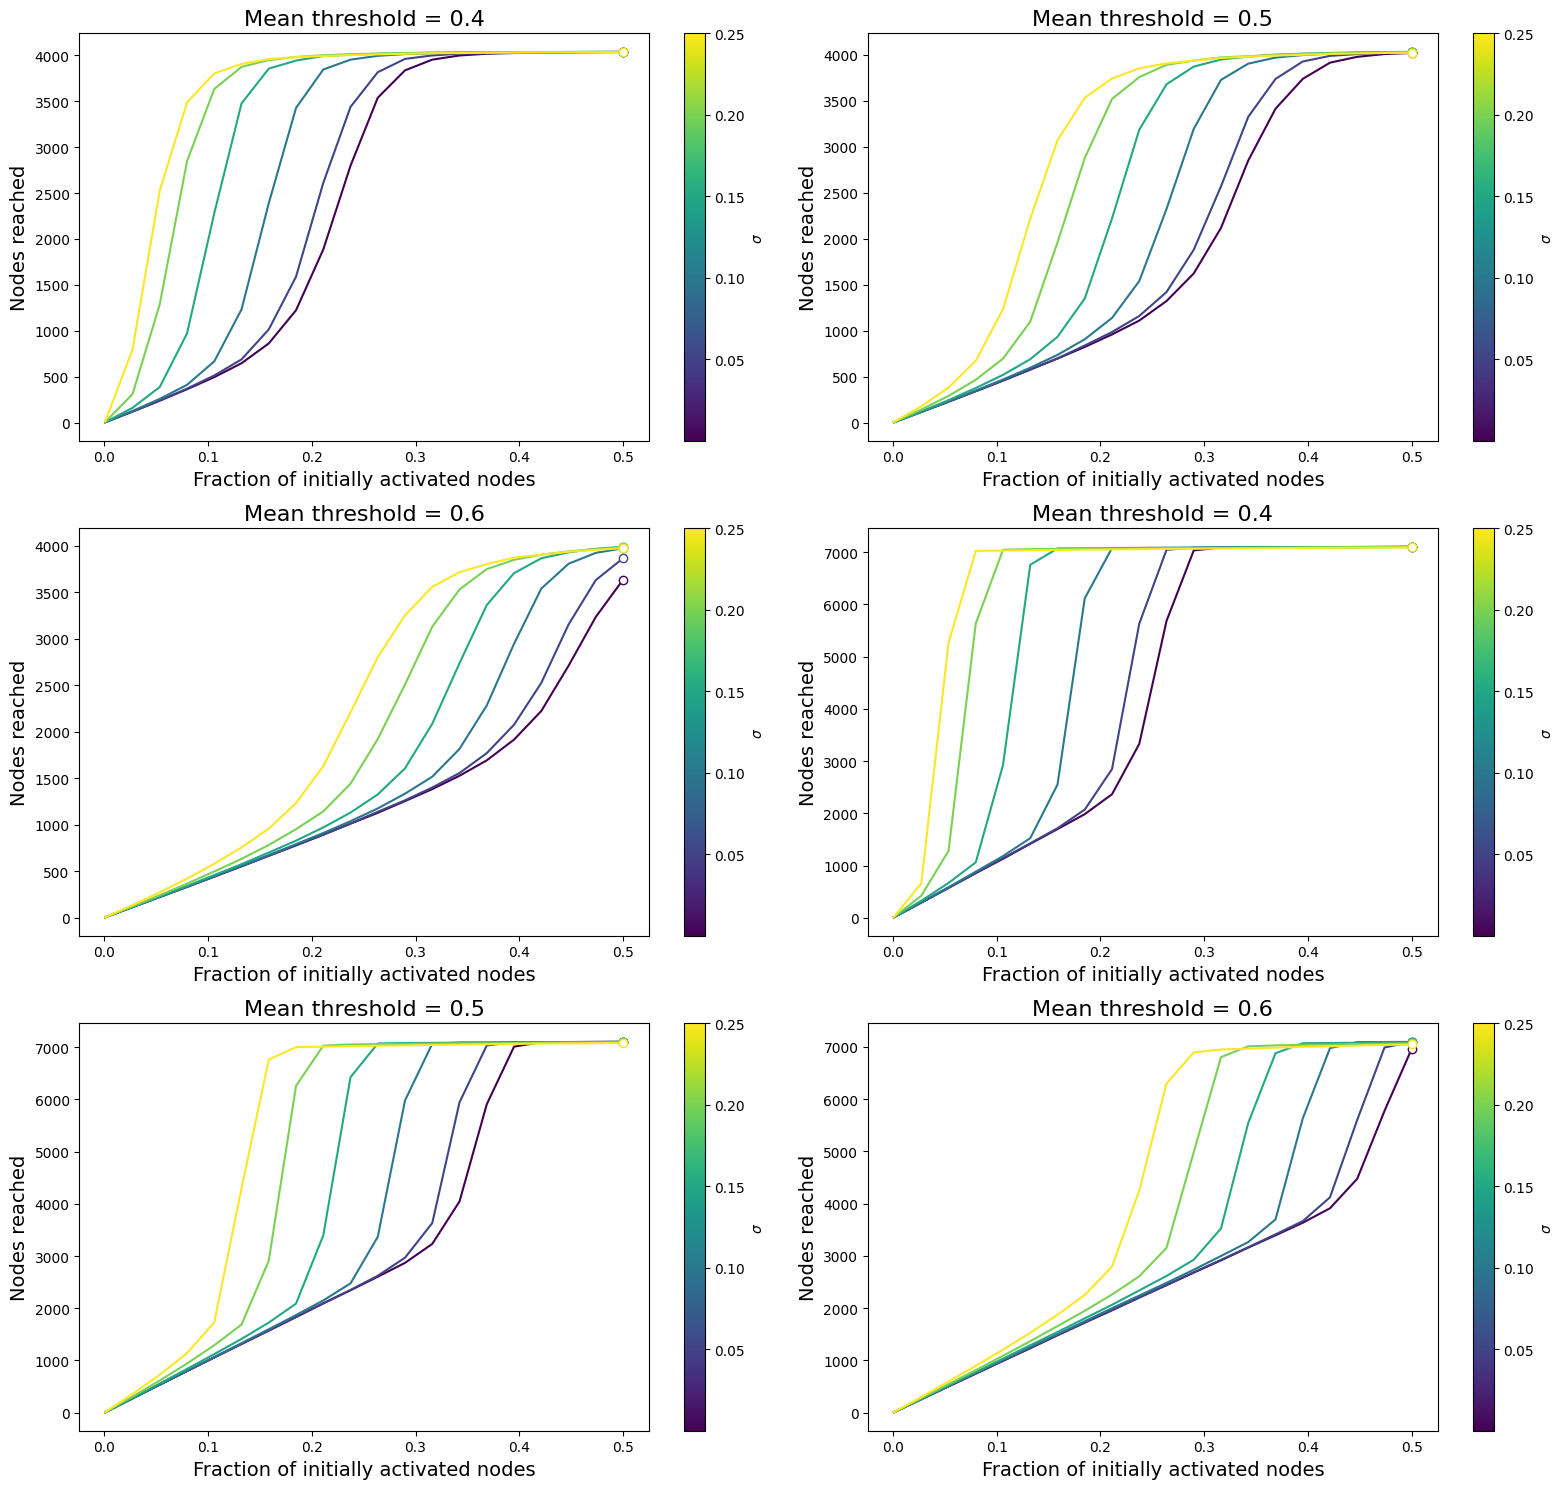

In [2]:
base_dir = "susceptibility_results"

# Find all mean folders
mean_dirs = sorted(glob.glob(os.path.join(base_dir, "*_mean_*")))

# Setup for subplots
n_means = len(mean_dirs)
n_rows = math.ceil(n_means / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.flatten()

# Color bar setup
cmap = plt.cm.viridis

# Each mean gets one graph
for ax, mean_dir in zip(axes, mean_dirs):

    # Setup filenames and sort by std value
    files = sorted(glob.glob(os.path.join(mean_dir, "std_*.pkl")))

    # Load data from files into curves list
    curves = []
    for file in files:
        with open(file, "rb") as f:
            curves.append(pickle.load(f))

    # Normalize std values for colorbar
    std_values = [curve["std"] for curve in curves]
    norm = plt.Normalize(min(std_values), max(std_values))

    for curve in curves:

        std = curve["std"]
        x = curve["fIA"]
        y = curve["Size"]

        sorted_curves = np.argsort(x)
        x = np.array(x)[sorted_curves]
        y = np.array(y)[sorted_curves]

        #P Plot curve
        ax.plot(x, y, color=cmap(norm(std)))

        # Plot peak on curve
        peak = np.argmax(y)
        ax.plot(
            x[peak],
            y[peak],
            "-o",
            color=cmap(norm(std)),
            markerfacecolor="white"
        )

    # Extract mean value for title
    mean_val = os.path.basename(mean_dir).split("_")[-1]

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label=r"$\sigma$")

    ax.set_title(f"Mean threshold = {mean_val}", fontsize=16)

    ax.set_ylabel("Nodes reached", fontsize=14)
    ax.set_xlabel('Fraction of initially activated nodes', fontsize=14)

plt.tight_layout()
plt.show()
